# Fair-pay checker: does a worker earn above the median for their job and state?

**AI for Good - Hackathon 5 "Model Showdown" · SDG 8.5 (equal pay for work of equal value)**

A worker-advice centre enters a member's job profile (occupation, industry, state, age, education, hours, weeks, type of employer).
The model estimates how likely it is that *people with this profile* earn **above the median hourly wage of their occupation in their state**.
If that probability is high but the member actually earns *below* the median, the centre has a reason to look closer: the member may be underpaid
and could use help to negotiate.

Data: US Census Bureau, American Community Survey (ACS) 2024 1-year Public Use Microdata Sample (PUMS), all 50 states + DC.
Models: a dummy baseline, KNN, logistic regression and histogram gradient boosting (scikit-learn).

**Runtime:** the first run downloads a 575 MB file from census.gov (a few minutes, sometimes slower, because census.gov limits download speed).
The file is cached in `data/`, so later runs skip the download. Tuning and evaluation take roughly 15–25 minutes on a standard Colab CPU.

In [1]:
import time
import urllib.request
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, confusion_matrix, f1_score,
                             precision_recall_curve, precision_score, recall_score, roc_auc_score)
from sklearn.model_selection import (GridSearchCV, GroupShuffleSplit, StratifiedGroupKFold,
                                     cross_val_predict, cross_validate)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

RANDOM_STATE = 42  # one seed for every split, sample and model, so the numbers are reproducible
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
print("python packages:", "pandas", pd.__version__, "| numpy", np.__version__,
      "| scikit-learn", sklearn.__version__, "| matplotlib", plt.matplotlib.__version__)

python packages: pandas 2.2.3 | numpy 2.4.6 | scikit-learn 1.6.1 | matplotlib 3.11.2


## 1. Frame the problem

**Target.** `y = 1` if a worker's hourly wage is **above the median hourly wage of workers in the same detailed occupation in the same state**, else `y = 0`.
The positive class is "above the median".
* *Hourly* wage = yearly wages ÷ (usual hours per week × weeks worked). With yearly wages, "below the median" would mostly mean "works part-time".
* *Within state*: a cashier in Massachusetts is compared with cashiers in Massachusetts, not with cashiers in Mississippi, because prices and pay levels differ a lot between states.
* The medians are computed **on the training set only** (step 4), so the test set does not influence its own labels.

**User and decision.** A worker-advice centre or union confederation that serves members in many sectors. For each member it decides whether to raise a
*"you may be underpaid"* signal and offer help with a pay negotiation. The signal is raised when the model says *people like you are usually above the median*
but the member's own wage is below it. The member's own wage alone is not enough: a 20-year-old without a degree is *expected* to earn below the median,
and that is not a sign of unfair pay. The model adds what is *typical for the profile*.

**Which mistake is worse?**
* *False positive* (the model predicts "above median" for someone who is below): in use, this person gets a wrong "you may be underpaid" signal.
  That can push them into a failed negotiation or a bad job switch.
* *False negative* (the model predicts "below median" for someone who is above): in use, a worker whose profile *should* earn more is not flagged and stays underpaid.

Both mistakes hurt the worker, and how many of each the tool makes depends on the probability threshold at which the centre raises the signal.

**Main metric: ROC-AUC.** The tool gives a *probability*, and the signal is raised only above a strict threshold (chosen in step 8). So the main question is whether
a higher probability really means "more likely above the median". ROC-AUC measures exactly that: pick one random above-median and one random below-median worker;
how often does the model give the first one the higher probability? 0.5 is a coin flip, 1.0 is perfect. Precision, recall and F1 are reported as well.

*Why not F1?* We first chose F1. But because about half of all workers are above their median (that is what a median does), a lazy rule that says "above" for
**everyone** already gets F1 ≈ 0.66: it finds every positive (recall 100%) and is right half the time (precision 49%). Such a rule is useless to the centre,
since it would tell every member they "should" earn more, but F1 ranked it above our real models. The "always above" rule is kept in the comparison table to show this.
ROC-AUC gives any rule that answers the same for everyone exactly 0.5.

**Size of the problem.** In the 2024 ACS, women working full-time, year-round earned 83% of men's median earnings; within some occupation groups it is 74%
([US Census Bureau, Equal Pay Day 2026](https://www.census.gov/newsroom/stories/equal-pay-day.html)). Part of that gap sits *within* the same occupation,
which is exactly what this tool tries to make visible.

## 2. Get the data and explore it

**Source.** ACS 2024 1-year PUMS, person file for the whole US (`csv_pus.zip`, 575 MB, two CSV files inside), plus the official data dictionary for code labels.
Public domain (a US federal government work). The Census Bureau anonymises the sample before release: it is a subset of responses,
some records are swapped, extreme values are top-coded, and there are no names or addresses.
The zip is too big for the repository, so this cell downloads it and caches it in `data/`.

In [2]:
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)
BASE = "https://www2.census.gov/programs-surveys/acs"
FILES = {
    "csv_pus.zip": f"{BASE}/data/pums/2024/1-Year/csv_pus.zip",
    "PUMS_Data_Dictionary_2024.csv": f"{BASE}/tech_docs/pums/data_dict/PUMS_Data_Dictionary_2024.csv",
}
for name, url in FILES.items():
    path = DATA_DIR / name
    if path.exists():
        print("already downloaded:", path)
        continue
    print("downloading", url, "...")
    start = time.time()
    tmp = path.with_suffix(".part")  # download under a temporary name, so a broken download is never mistaken for a complete file
    urllib.request.urlretrieve(url, tmp)
    tmp.rename(path)
    print(f"  done in {time.time() - start:.0f} s")

already downloaded: data\csv_pus.zip
already downloaded: data\PUMS_Data_Dictionary_2024.csv


We load only the columns we need (the file has 280+ columns). Used as **features**: occupation, industry, age, education, hours, weeks, class of worker.
Used **only to build the target**: wages, the income adjustment factor and state. Used **only for the fairness audit** (never shown to the model): sex,
race, Hispanic origin and citizenship. Household id and person number are used for the group-aware split and the duplicate check.

In [3]:
COLS = ["SERIALNO", "SPORDER", "STATE", "ADJINC", "WAGP", "WKHP", "WKWN", "ESR", "COW",
        "OCCP", "INDP", "AGEP", "SCHL", "SEX", "RAC1P", "HISP", "CIT"]
start = time.time()
with zipfile.ZipFile(DATA_DIR / "csv_pus.zip") as z:
    raw = pd.concat([pd.read_csv(z.open(n), usecols=COLS, dtype={"SERIALNO": str})
                     for n in ("psam_pusa.csv", "psam_pusb.csv")], ignore_index=True)
print(f"loaded {len(raw):,} persons x {raw.shape[1]} columns in {time.time() - start:.0f} s")
raw.head()

loaded 3,422,888 persons x 17 columns in 36 s


,SERIALNO,SPORDER,STATE,ADJINC,AGEP,CIT,COW,SCHL,SEX,WAGP,WKHP,WKWN,ESR,HISP,INDP,OCCP,RAC1P
0,2024GQ0000060,1,1,1015250,59,1,1.0,10.0,1,18500.0,30.0,52.0,6.0,1,9070.0,8300.0,2
1,2024GQ0000094,1,1,1015250,43,1,NaN,17.0,1,0.0,NaN,NaN,6.0,1,NaN,NaN,1
2,2024GQ0000146,1,1,1015250,75,1,NaN,16.0,2,0.0,NaN,NaN,6.0,1,NaN,NaN,2
3,2024GQ0000156,1,1,1015250,22,3,1.0,19.0,2,0.0,NaN,NaN,6.0,1,3365.0,7010.0,6
4,2024GQ0000182,1,1,1015250,51,1,NaN,16.0,1,0.0,NaN,NaN,6.0,1,NaN,NaN,1


**Population filters.** We keep employed wage and salary workers of working age, and record how many rows each filter drops:
* age 18–64 (working age);
* civilian employed now (`ESR` 1 or 2). Armed forces are excluded because military pay follows fixed tables;
* employees (`COW` 1–5). Self-employed and unpaid family workers do not have a wage that can be compared;
* positive wages; more than 4 weeks worked and more than 5 usual hours per week. For very marginal jobs, the hourly wage computed from yearly
  survey answers is unreliable;
* hourly wage at least $2. Anything lower is below every legal US minimum wage (the tipped minimum is $2.13), so it is a reporting error.

`ADJINC` converts the reported wages to 2024 dollars (as stated by the ACS documentation). It has 6 implied decimals, so we divide by 1,000,000.

In [4]:
raw["hourly"] = raw.WAGP * raw.ADJINC / 1e6 / (raw.WKHP * raw.WKWN)  # NaN for people without hours/weeks

FILTERS = [
    ("age 18-64", lambda d: d.AGEP.between(18, 64)),
    ("civilian employed (ESR 1-2)", lambda d: d.ESR.isin([1, 2])),
    ("employee, not self-employed (COW 1-5)", lambda d: d.COW.isin([1, 2, 3, 4, 5])),
    ("wages > 0", lambda d: d.WAGP > 0),
    ("more than 4 weeks worked", lambda d: d.WKWN > 4),
    ("more than 5 usual hours/week", lambda d: d.WKHP > 5),
    ("hourly wage >= $2", lambda d: d.hourly >= 2),
]
workers, log = raw, [("all persons in the file", len(raw), None)]
for reason, rule in FILTERS:
    before = len(workers)
    workers = workers[rule(workers)]
    log.append((reason, len(workers), before - len(workers)))
del raw  # free memory
workers = workers.copy()
pd.DataFrame(log, columns=["filter", "rows left", "rows dropped"])

,filter,rows left,rows dropped
0,all persons in the file,3422888,NaN
1,age 18-64,1976963,1445925.0
2,civilian employed (ESR 1-2),1429593,547370.0
3,"employee, not self-employed (COW 1-5)",1290253,139340.0
4,wages > 0,1290253,0.0
5,more than 4 weeks worked,1279839,10414.0
6,more than 5 usual hours/week,1271489,8350.0
7,hourly wage >= $2,1268428,3061.0


**Readable labels.** The data dictionary gives each occupation and industry code a label such as `MGR-Chief Executives And Legislators`.
The prefix before the dash is the broad group (e.g. MGR = management). We use it as an extra feature (`occ_group`, `ind_group`)
and as the "sector" for the audit. The full names of all group codes are in the table below. The audit columns are recoded into a few readable groups.

In [5]:
dd = pd.read_csv(DATA_DIR / "PUMS_Data_Dictionary_2024.csv", header=None, names=range(7), dtype=str)

def code_labels(var):
    v = dd[(dd[0] == "VAL") & (dd[1] == var) & dd[4].str.isdigit()]
    return dict(zip(v[4].astype(int), v[6]))

OCC_LABEL, IND_LABEL, STATE_LABEL = code_labels("OCCP"), code_labels("INDP"), code_labels("STATE")

workers["OCCP"] = workers.OCCP.astype(int)
workers["INDP"] = workers.INDP.astype(int)
workers["occ_group"] = workers.OCCP.map(OCC_LABEL).str.split("-", n=1).str[0]
workers["ind_group"] = workers.INDP.map(IND_LABEL).str.split("-", n=1).str[0]
assert workers[["occ_group", "ind_group"]].notna().all().all(), "every code should have a label"

# full names of the group codes (Census occupation and industry groups, checked against the labels in the data dictionary)
OCC_GROUP_NAME = {
    "MGR": "Management", "BUS": "Business operations", "FIN": "Financial specialists", "CMM": "Computer and mathematical",
    "ENG": "Architecture and engineering", "SCI": "Life, physical and social science", "CMS": "Community and social service",
    "LGL": "Legal", "EDU": "Education, training and library", "ENT": "Arts, design, entertainment, sports and media",
    "MED": "Healthcare practitioners and technical", "HLS": "Healthcare support", "PRT": "Protective service",
    "EAT": "Food preparation and serving", "CLN": "Building and grounds cleaning and maintenance", "PRS": "Personal care and service",
    "SAL": "Sales", "OFF": "Office and administrative support", "FFF": "Farming, fishing and forestry", "CON": "Construction",
    "EXT": "Extraction (mining, oil and gas)", "RPR": "Installation, maintenance and repair", "PRD": "Production",
    "TRN": "Transportation and material moving",
}
IND_GROUP_NAME = {
    "AGR": "Agriculture, forestry, fishing and hunting", "EXT": "Mining, oil and gas extraction", "UTL": "Utilities",
    "CON": "Construction", "MFG": "Manufacturing", "WHL": "Wholesale trade", "RET": "Retail trade",
    "TRN": "Transportation and warehousing", "INF": "Information (publishing, media, telecom)",
    "FIN": "Finance, insurance and real estate", "PRF": "Professional, scientific, management, administrative and waste services",
    "EDU": "Educational services", "MED": "Health care", "SCA": "Social assistance (incl. child care)",
    "ENT": "Arts, entertainment, recreation, accommodation and food services", "SRV": "Other services (repair, personal care, organisations)",
    "ADM": "Public administration",
}
assert workers.occ_group.isin(OCC_GROUP_NAME).all() and workers.ind_group.isin(IND_GROUP_NAME).all()

# audit-only columns (never used as features)
workers["sex"] = workers.SEX.map({1: "male", 2: "female"})
workers["race_eth"] = np.where(workers.HISP != 1, "Hispanic",
                               workers.RAC1P.map({1: "White", 2: "Black", 6: "Asian"}).fillna("Other/multiple"))
workers["migration"] = workers.CIT.map({1: "born US citizen", 2: "born US citizen", 3: "born US citizen",
                                        4: "naturalised citizen", 5: "non-citizen"})
print(workers.occ_group.nunique(), "occupation groups,", workers.OCCP.nunique(), "detailed occupations,",
      workers.ind_group.nunique(), "industry groups,", workers.STATE.nunique(), "states (incl. DC)")

24 occupation groups, 525 detailed occupations, 17 industry groups, 51 states (incl. DC)


In [6]:
# the group codes used in the rest of the notebook, with the number of workers in each
codes = pd.concat([
    pd.DataFrame({"code": list(OCC_GROUP_NAME), "name": list(OCC_GROUP_NAME.values()), "type": "occupation group"}),
    pd.DataFrame({"code": list(IND_GROUP_NAME), "name": list(IND_GROUP_NAME.values()), "type": "industry group"}),
])
codes["workers"] = [(workers.occ_group if t == "occupation group" else workers.ind_group).eq(c).sum()
                    for c, t in zip(codes.code, codes.type)]
codes.set_index(["type", "code"])

name  workers
type             code                                                            
occupation group MGR                                          Management   151255
                 BUS                                 Business operations    55023
                 FIN                               Financial specialists    28963
                 CMM                           Computer and mathematical    58162
                 ENG                        Architecture and engineering    34168
                 SCI                   Life, physical and social science    17416
                 CMS                        Community and social service    25005
                 LGL                                               Legal    14364
                 EDU                     Education, training and library    94000
                 ENT       Arts, design, entertainment, sports and media    21842
                 MED              Healthcare practitioners and technical    92224
                 HLS                                  Healthcare support    40363
                 PRT                                  Protective service    28715
                 EAT                        Food preparation and serving    60549
                 CLN       Building and grounds cleaning and maintenance    31988
                 PRS                           Personal care and service    22822
                 SAL                                               Sales   100486
                 OFF                   Office and administrative support   138560
                 FFF                       Farming, fishing and forestry     6925
                 CON                                        Construction    48494
                 EXT                    Extraction (mining, oil and gas)     1470
                 RPR                Installation, maintenance and repair    39125
                 PRD                                          Production    67986
                 TRN                  Transportation and material moving    88523
industry group   AGR          Agriculture, forestry, fishing and hunting    12057
                 EXT                      Mining, oil and gas extraction     5299
                 UTL                                           Utilities    13860
                 CON                                        Construction    73224
                 MFG                                       Manufacturing   138126
                 WHL                                     Wholesale trade    24941
                 RET                                        Retail trade   130534
                 TRN                      Transportation and warehousing    57112
                 INF            Information (publishing, media, telecom)    24577
                 FIN                  Finance, insurance and real estate    82670
                 PRF   Professional, scientific, management, administ...   152914
                 EDU                                Educational services   144781
                 MED                                         Health care   161994
                 SCA                Social assistance (incl. child care)    27471
                 ENT   Arts, entertainment, recreation, accommodation...    98800
                 SRV   Other services (repair, personal care, organis...    48115
                 ADM                               Public administration    71953

### Explore

Size, types, missing values, duplicates and impossible values.

In [7]:
NUM = ["AGEP", "SCHL", "WKHP", "WKWN"]         # age, education (ordered code 1-24), usual hours/week, weeks worked
CAT = ["OCCP", "occ_group", "ind_group", "COW"]  # detailed occupation, occupation group, industry group, class of worker
FEATURES = NUM + CAT
AUDIT = ["sex", "race_eth", "migration"]

print(f"{len(workers):,} workers")
print("missing values per column:\n", workers[FEATURES + AUDIT + ["hourly", "STATE"]].isna().sum().to_string())
print("duplicate persons (same household id + person number):", workers.duplicated(["SERIALNO", "SPORDER"]).sum())
print("rows identical on all features:", f"{workers.duplicated(FEATURES).mean():.1%}",
      "(different people who share the same profile, not copied rows)")
workers[NUM + ["hourly"]].describe(percentiles=[0.01, 0.5, 0.99]).round(1)

1,268,428 workers


missing values per column:
 AGEP         0
SCHL         0
WKHP         0
WKWN         0
OCCP         0
occ_group    0
ind_group    0
COW          0
sex          0
race_eth     0
migration    0
hourly       0
STATE        0


duplicate persons (same household id + person number): 0


rows identical on all features: 36.7% (different people who share the same profile, not copied rows)


,AGEP,SCHL,WKHP,WKWN,hourly
count,1268428.0,1268428.0,1268428.0,1268428.0,1268428.0
mean,41.2,18.9,39.5,49.5,36.7
std,13.0,3.4,10.7,8.0,44.6
min,18.0,1.0,6.0,5.0,2.0
1%,18.0,1.0,8.0,10.0,3.4
50%,41.0,20.0,40.0,52.0,26.4
99%,64.0,24.0,72.0,52.0,216.9
max,64.0,24.0,99.0,52.0,10755.3


* No missing values remain after the filters (every employed person answered these questions or the Census Bureau imputed the answer). So the pipeline needs no imputer.
* No person appears twice. Many rows share the same feature *values*, but those are different people with the same profile.
  That is normal for survey data and cannot leak information between train and test.
* Impossible values: age and weeks are within range. Hours are top-coded at 99 ("99 or more"), and wages are top-coded by the Census Bureau.
  This affects only the highest earners, who are above their median either way.
* The hourly wage has a long right tail (the 99th percentile is far above the median), so it is shown on a log scale below.

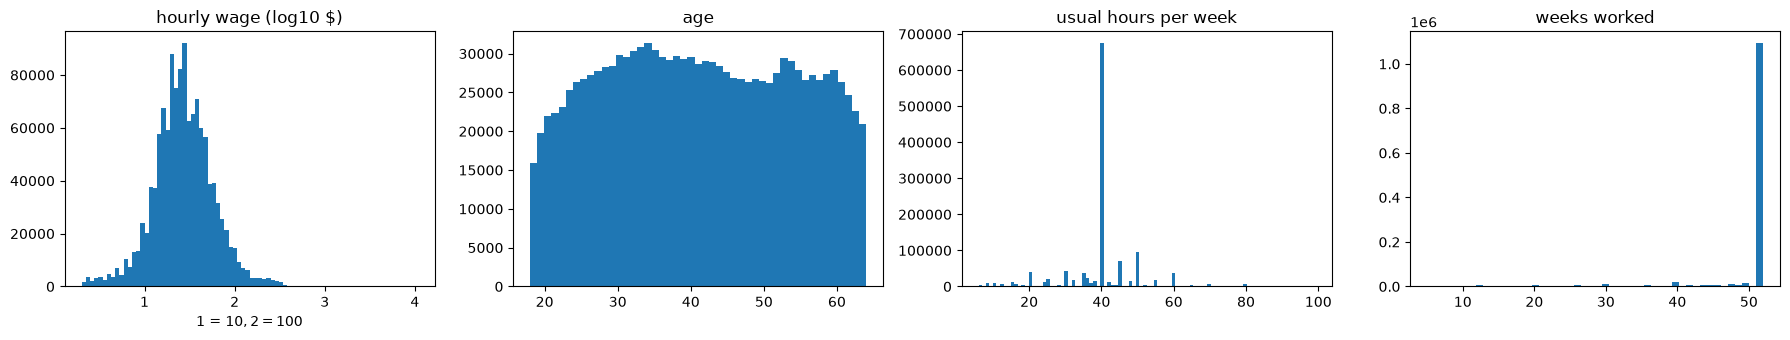

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(18, 3.5))
axes[0].hist(np.log10(workers.hourly), bins=80)
axes[0].set(title="hourly wage (log10 $)", xlabel="1 = $10, 2 = $100")
axes[1].hist(workers.AGEP, bins=47); axes[1].set(title="age")
axes[2].hist(workers.WKHP, bins=94); axes[2].set(title="usual hours per week")
axes[3].hist(workers.WKWN, bins=48); axes[3].set(title="weeks worked")
plt.tight_layout(); plt.show()

**Leakage check.** Wages (`WAGP`), the hourly wage and every other income column are *outcomes*, so none of them is a feature.
Hours and weeks are used in the hourly-wage formula, but they describe the job and the worker knows them before any pay comparison, so they are allowed as features.
Detailed industry (270 codes) is reduced to its group to keep the number of columns manageable.
**State** is not a feature: the target is already defined *within* each state.

## 3. Split first

We put 20% of the data aside as the test set **before** computing medians, scaling or tuning.
* **Group-aware:** about two thirds of workers share a household with another worker in the sample. Partners and family members are similar (same place, often similar jobs),
  so we split by household (`SERIALNO`). Nobody in the test set has a housemate in the training set.
* **Not stratified on the target:** the target does not exist yet, because its medians are computed on the training part.
  With over a million rows, a random household split gives the same class balance in both parts. We check this below.

In [9]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(workers, groups=workers.SERIALNO))
train_all, test_all = workers.iloc[train_idx], workers.iloc[test_idx]
assert not set(train_all.SERIALNO) & set(test_all.SERIALNO), "a household is in both train and test"
print(f"train: {len(train_all):,} workers | test: {len(test_all):,} workers")

train: 1,014,613 workers | test: 253,815 workers


**Target from training data only.** For each state × occupation cell we compute the median hourly wage on the **training set**.
A cell is used only if it has **at least 30 training workers**; a median of fewer people is too noisy. Workers in smaller cells are **"not covered"**:
the model gives them no prediction at all. The same training medians are used to label the test set.

In [10]:
MIN_CELL = 30
cells = (train_all.groupby(["STATE", "OCCP"]).hourly
         .agg(cell_median="median", cell_n="size").reset_index())
covered_cells = cells[cells.cell_n >= MIN_CELL]

def add_target(d):
    d = d.merge(covered_cells[["STATE", "OCCP", "cell_median"]], on=["STATE", "OCCP"], how="left")
    d["covered"] = d.cell_median.notna()
    d["y"] = (d.hourly > d.cell_median).astype(int)
    return d

train_all, test_all = add_target(train_all), add_target(test_all)
print(f"{len(covered_cells):,} of {len(cells):,} state x occupation cells have >= {MIN_CELL} training workers")
print(f"covered workers: train {train_all.covered.mean():.1%}, test {test_all.covered.mean():.1%}")

# who is NOT covered? (an equity question: the tool cannot help these people)
print("\nshare of training workers NOT covered, per group:")
for col in AUDIT + ["occ_group"]:
    print(" ", (1 - train_all.groupby(col).covered.mean()).round(3).sort_values(ascending=False).head(6).to_dict())
by_state = 1 - train_all.groupby(train_all.STATE.map(STATE_LABEL)).covered.mean()
print("  states with the lowest coverage:", by_state.sort_values(ascending=False).head(5).round(2).to_dict())

6,415 of 23,239 state x occupation cells have >= 30 training workers
covered workers: train 86.0%, test 85.6%

share of training workers NOT covered, per group:
  {'male': 0.151, 'female': 0.129}
  {'Other/multiple': 0.168, 'White': 0.158, 'Black': 0.125, 'Hispanic': 0.093, 'Asian': 0.092}


  {'born US citizen': 0.149, 'non-citizen': 0.094, 'naturalised citizen': 0.091}
  {'EXT': 0.797, 'ENT': 0.431, 'SCI': 0.428, 'PRS': 0.315, 'RPR': 0.281, 'CMS': 0.258}
  states with the lowest coverage: {'Vermont/VT': 0.81, 'Alaska/AK': 0.8, 'Wyoming/WY': 0.77, 'North Dakota/ND': 0.72, 'Delaware/DE': 0.69}


In [11]:
train = train_all[train_all.covered].reset_index(drop=True)
test = test_all[test_all.covered].reset_index(drop=True)
print(f"class balance (share above median): train {train.y.mean():.3f} | test {test.y.mean():.3f}")
print("(slightly below 0.5 because workers paid exactly the median count as 'not above')\n")
print("share above the median per group (training set):")
for col in AUDIT + ["occ_group"]:
    print(" ", train.groupby(col).y.mean().round(3).sort_values().to_dict())

class balance (share above median): train 0.491 | test 0.492
(slightly below 0.5 because workers paid exactly the median count as 'not above')

share above the median per group (training set):
  {'female': 0.455, 'male': 0.526}
  {'Hispanic': 0.431, 'Black': 0.462, 'Other/multiple': 0.463, 'White': 0.509, 'Asian': 0.529}
  {'non-citizen': 0.449, 'born US citizen': 0.488, 'naturalised citizen': 0.549}


  {'EXT': 0.485, 'CLN': 0.487, 'PRT': 0.487, 'PRD': 0.487, 'RPR': 0.487, 'ENT': 0.488, 'CON': 0.488, 'CMS': 0.488, 'PRS': 0.488, 'FIN': 0.489, 'ENG': 0.489, 'OFF': 0.49, 'SCI': 0.49, 'TRN': 0.49, 'MED': 0.49, 'HLS': 0.491, 'BUS': 0.491, 'CMM': 0.492, 'EAT': 0.492, 'MGR': 0.492, 'LGL': 0.492, 'EDU': 0.493, 'FFF': 0.493, 'SAL': 0.493}


The classes are balanced overall, as they should be by construction. **They are not balanced per group:** within the same occupation and state,
women, Black and Hispanic workers and non-citizens are less often above the median. This is the pay gap the tool is about. It also means
a model that only learns "who is usually above the median" can repeat that pattern. We check this in step 8.

**Working samples.** The medians above use all ~870k training workers. KNN has to compare every prediction with every training row, and tuning repeats this
dozens of times, which is too slow for Colab at full size. So we **tune and fit all models on the same fixed random sample of 20,000 training workers** and
**evaluate on a fixed random sample of 50,000 test workers**. Both samples are drawn with the same seed, so every model sees exactly the same rows.

In [12]:
N_TUNE, N_TEST = 20_000, 50_000
tune = train.sample(N_TUNE, random_state=RANDOM_STATE)
test_s = test.sample(N_TEST, random_state=RANDOM_STATE)
X_tune, y_tune = tune[FEATURES], tune.y
X_test, y_test = test_s[FEATURES], test_s.y
print(f"tuning sample: {len(tune):,} rows, {y_tune.mean():.3f} positive | test sample: {len(test_s):,} rows, {y_test.mean():.3f} positive")

tuning sample: 20,000 rows, 0.494 positive | test sample: 50,000 rows, 0.495 positive


## 4. Pre-processing inside a pipeline

One `ColumnTransformer` for all models, fitted on training data only (inside each CV fold, then on the tuning sample):
* **Numbers** (age, education code, hours, weeks) are **standardised** (mean 0, sd 1). KNN measures distances, so without scaling "hours" (range 5–99)
  would count far more than "education" (1–24). Logistic regression's penalty `C` shrinks all coefficients equally, which is only fair when the features are on the same scale.
  The tree-based model does not need scaling, but it does no harm, and one shared preprocessor keeps the comparison simple.
* **Categories** (detailed occupation, occupation group, industry group, class of worker) are **one-hot encoded**. `handle_unknown="ignore"` means a category
  never seen in training becomes all zeros instead of an error.
* Education (`SCHL`) is kept as one number, because its codes are ordered from "no schooling" (1) to "doctorate" (24).
* The detailed occupations make up most of the ~440 columns after encoding. That makes KNN's distances noisy: two workers in different occupations are equally far apart
  whether the jobs are similar or not. We keep the column anyway, because it lets the models learn that, for example, age matters more in some jobs.
  By construction each occupation has about 50% positives, so the occupation *on its own* hardly predicts the target.

In [13]:
def make_preprocessor():
    return ColumnTransformer([
        ("num", StandardScaler(), NUM),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CAT),
    ])

print(make_preprocessor().fit(X_tune).transform(X_tune).shape[1], "columns after encoding")

437 columns after encoding


## 5. Baselines

* `DummyClassifier(strategy="most_frequent")` always predicts the larger class. Here that is "not above" (51%), so its F1 is 0 and its ROC-AUC is 0.5.
* `DummyClassifier(strategy="constant", constant=1)` always says "above": the lazy rule from step 1. Its F1 is high, but its ROC-AUC is also 0.5.
* A stronger simple alternative: the **best single threshold on one feature** (a decision tree of depth 1, e.g. "age above X → above median").
  Machine learning is only worth it if it clearly beats this rule.

All cross-validation uses the **same 5 folds**: stratified on the target and grouped by household, so the class balance is equal in every fold and
housemates stay in the same fold.

In [14]:
folds = list(StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
             .split(X_tune, y_tune, groups=tune.SERIALNO))

baselines = {
    "Dummy (most frequent)": Pipeline([("prep", make_preprocessor()), ("model", DummyClassifier(strategy="most_frequent"))]),
    "Dummy (always above)": Pipeline([("prep", make_preprocessor()), ("model", DummyClassifier(strategy="constant", constant=1))]),
    "Single threshold (depth-1 tree)": Pipeline([("prep", make_preprocessor()),
                                                  ("model", DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE))]),
}
cv_rows = {}
for name, pipe in baselines.items():
    r = cross_validate(pipe, X_tune, y_tune, cv=folds, scoring=["roc_auc", "f1"])
    cv_rows[name] = dict(params="-", cv_mean=r["test_roc_auc"].mean(), cv_std=r["test_roc_auc"].std())
    print(f"{name}: CV ROC-AUC = {r['test_roc_auc'].mean():.3f} ± {r['test_roc_auc'].std():.3f}"
          f" | CV F1 = {r['test_f1'].mean():.3f} ± {r['test_f1'].std():.3f}")

Dummy (most frequent): CV ROC-AUC = 0.500 ± 0.000 | CV F1 = 0.000 ± 0.000


Dummy (always above): CV ROC-AUC = 0.500 ± 0.000 | CV F1 = 0.661 ± 0.007


Single threshold (depth-1 tree): CV ROC-AUC = 0.587 ± 0.008 | CV F1 = 0.662 ± 0.007


## 6. Tune with cross-validation (training sample only)

`GridSearchCV` with the same folds and the same metric (ROC-AUC) for all three models:
* **KNN** – `n_neighbors` (k): small k follows individual neighbours (risk of overfitting), large k averages over many (risk of underfitting).
* **Logistic regression** – the type of penalty and its strength `C`. The penalty keeps the coefficients small so the model does not chase noise in the training data:
  * **L2 (ridge)** adds the *squared* coefficients to the loss. All coefficients shrink towards zero, but none becomes exactly zero. This is scikit-learn's default.
  * **L1 (lasso)** adds the *absolute* coefficients. It pushes unimportant coefficients to **exactly zero**, so it also selects features. With ~440 one-hot columns
    (mostly detailed occupations), that can switch off occupations that add nothing.
  * `C` is the inverse strength of either penalty: small C means strong shrinking and a simpler model.
  We use the `liblinear` solver because the default solver (`lbfgs`) cannot do L1.
* **HistGradientBoosting** (our own choice) – a fast gradient-boosted tree ensemble that works well on tabular data with many rows and can learn interactions
  (e.g. "experience pays off more in management") that logistic regression cannot. We tune `learning_rate` (how big each correction step is) and `max_leaf_nodes`
  (how complex each tree is). The number of trees is chosen by the model's built-in early stopping on 10% of each training fold.

In [15]:
GRIDS = {
    "KNN": (KNeighborsClassifier(), {"model__n_neighbors": [15, 51, 101, 201]}),
    "Logistic regression": (LogisticRegression(solver="liblinear", max_iter=2000, random_state=RANDOM_STATE),
                            {"model__penalty": ["l1", "l2"], "model__C": [0.001, 0.01, 0.1, 1, 10]}),
    "HistGradientBoosting": (HistGradientBoostingClassifier(random_state=RANDOM_STATE),
                             {"model__learning_rate": [0.05, 0.1], "model__max_leaf_nodes": [15, 31, 63]}),
}
searches = {}
for name, (model, grid) in GRIDS.items():
    start = time.time()
    search = GridSearchCV(Pipeline([("prep", make_preprocessor()), ("model", model)]), grid,
                          cv=folds, scoring="roc_auc", return_train_score=True, n_jobs=-1)
    search.fit(X_tune, y_tune)
    searches[name] = search
    i = search.best_index_
    res = search.cv_results_
    cv_rows[name] = dict(params=", ".join(f"{k.replace('model__', '')}={v}" for k, v in search.best_params_.items()),
                         cv_mean=res["mean_test_score"][i], cv_std=res["std_test_score"][i])
    print(f"{name}: best {search.best_params_} | CV ROC-AUC = {res['mean_test_score'][i]:.3f} ± {res['std_test_score'][i]:.3f}"
          f" | {time.time() - start:.0f} s")

KNN: best {'model__n_neighbors': 101} | CV ROC-AUC = 0.662 ± 0.009 | 59 s


Logistic regression: best {'model__C': 0.1, 'model__penalty': 'l2'} | CV ROC-AUC = 0.645 ± 0.007 | 5 s


HistGradientBoosting: best {'model__learning_rate': 0.1, 'model__max_leaf_nodes': 31} | CV ROC-AUC = 0.688 ± 0.012 | 246 s


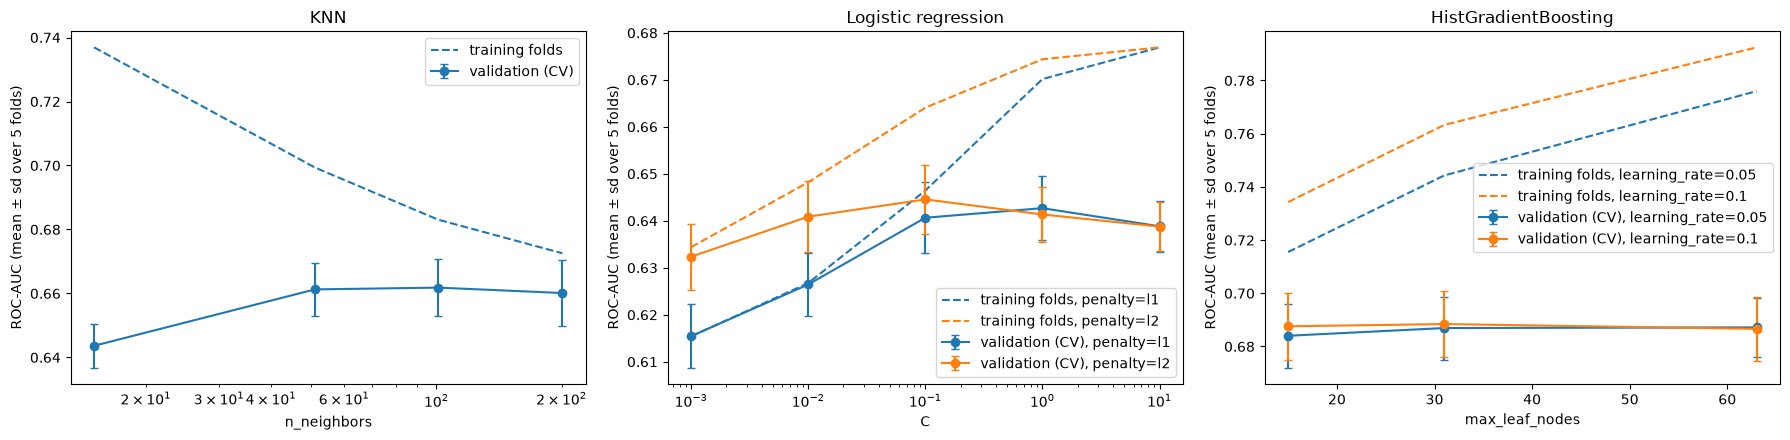

,params,CV ROC-AUC
Dummy (most frequent),-,0.500 ± 0.000
Dummy (always above),-,0.500 ± 0.000
Single threshold (depth-1 tree),-,0.587 ± 0.008
KNN,n_neighbors=101,0.662 ± 0.009
Logistic regression,"C=0.1, penalty=l2",0.645 ± 0.007
HistGradientBoosting,"learning_rate=0.1, max_leaf_nodes=31",0.688 ± 0.012


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
for ax, (name, param) in zip(axes, [("KNN", "n_neighbors"), ("Logistic regression", "C"),
                                     ("HistGradientBoosting", "max_leaf_nodes")]):
    res = pd.DataFrame(searches[name].cv_results_)
    # one line per learning rate (HGB) or per penalty type (logistic regression)
    split_by = {"HistGradientBoosting": "learning_rate", "Logistic regression": "penalty"}.get(name)
    groups = res.groupby(f"param_model__{split_by}") if split_by else [(None, res)]
    for value, g in groups:
        suffix = f", {split_by}={value}" if split_by else ""
        bars = ax.errorbar(g[f"param_model__{param}"].astype(float), g.mean_test_score, yerr=g.std_test_score,
                           marker="o", capsize=3, label="validation (CV)" + suffix)
        # dashed line in the same colour: score on the training folds (a big gap to validation = overfitting)
        ax.plot(g[f"param_model__{param}"].astype(float), g.mean_train_score, "--",
                color=bars[0].get_color(), label="training folds" + suffix)
    if name != "HistGradientBoosting":
        ax.set_xscale("log")
    ax.set(title=name, xlabel=param, ylabel="ROC-AUC (mean ± sd over 5 folds)")
    ax.legend()
plt.tight_layout(); plt.show()

cv_table = pd.DataFrame(cv_rows).T
cv_table["CV ROC-AUC"] = cv_table.apply(lambda r: f"{r.cv_mean:.3f} ± {r.cv_std:.3f}", axis=1)
cv_table[["params", "CV ROC-AUC"]]

**L1 vs L2 in detail.** We refit logistic regression with each penalty at its own best `C` and compare the coefficients: how many does each penalty set to exactly zero,
and which features weigh most? (Numbers are standardised and categories one-hot encoded, so coefficients are comparable: a positive one raises the chance of "above median".)

In [17]:
lr_res = pd.DataFrame(searches["Logistic regression"].cv_results_)
coef_rows, coefs = {}, {}
for penalty, g in lr_res.groupby("param_model__penalty"):
    best = g.loc[g.mean_test_score.idxmax()]
    pipe = clone(searches["Logistic regression"].best_estimator_).set_params(model__penalty=penalty, model__C=best.param_model__C)
    pipe.fit(X_tune, y_tune)
    coefs[penalty] = pd.Series(pipe.named_steps["model"].coef_[0], index=pipe.named_steps["prep"].get_feature_names_out())
    is_occ = coefs[penalty].index.str.startswith("cat__OCCP_")
    coef_rows[penalty] = {"best C": best.param_model__C,
                          "CV ROC-AUC": f"{best.mean_test_score:.3f} ± {best.std_test_score:.3f}",
                          "coefficients": len(coefs[penalty]),
                          "exactly zero": int((coefs[penalty] == 0).sum()),
                          "detailed occupations set to zero": f"{int((coefs[penalty][is_occ] == 0).sum())} of {is_occ.sum()}"}
display(pd.DataFrame(coef_rows).T)

# the 12 strongest coefficients of each penalty, with occupation codes replaced by their names
def readable(feature):
    col = feature.split("__", 1)[1]
    return OCC_LABEL[int(col[5:])] if col.startswith("OCCP_") else col
both = pd.DataFrame(coefs).rename(index=readable)
both.reindex(both.l2.abs().sort_values(ascending=False).index).head(12).round(3)

,best C,CV ROC-AUC,coefficients,exactly zero,detailed occupations set to zero
l1,1.0,0.643 ± 0.007,437,189,184 of 387
l2,0.1,0.645 ± 0.007,437,0,0 of 387


,l1,l2
occ_group_EAT,0.904,0.706
OFF-Postal Service Mail Carriers,-1.233,-0.600
RPR-Automotive Service Technicians And Mechanics,0.916,0.580
ind_group_UTL,0.662,0.551
MGR-Food Service Managers,0.876,0.539
ind_group_SCA,-0.703,-0.517
MED-Medical Records Specialists,-1.730,-0.483
AGEP,0.457,0.447
COW_5.0,0.596,0.445
occ_group_FIN,-0.417,-0.444


**What L1 shows us.** At the same score, L1 sets **189 of 437 coefficients to exactly zero, including 184 of the 387 detailed occupations**. For about half of the occupations,
knowing the exact job adds nothing beyond its occupation group. That fits the design: the target already compares each worker with their own occupation's median.
L2 keeps every coefficient, but it shrinks them. The table of strongest coefficients should be read with care:
* **Age** (+0.45 per standard deviation) and **federal government employer** (`COW_5`, +0.45 to +0.60) are clear, stable effects.
* The large coefficients of single occupations and groups (e.g. "Meeting, convention and event planners": +1.94 under L1, +0.43 under L2) are **not** stable.
  A detailed occupation always belongs to the same occupation group, so the model can split the effect between the two columns in many ways, and rare occupations have few training rows.
  This is also why L1 and L2 disagree most on exactly these columns.
* L1 would be the better choice if a short, explainable list of features mattered most, since it scores the same with 43% fewer coefficients. We keep the grid's choice (L2)
  so that every model is chosen by the same rule. Logistic regression is not the recommended model either way.

**Reading the curves.**
* **KNN:** with k = 15 the training folds score far higher than validation (it memorises neighbours). Validation improves up to k ≈ 50–100 and then flattens. Best: k = 101.
* **Logistic regression:** a very small C (strong penalty) underfits. Above the best C the training score keeps rising while validation drops slightly, which is overfitting.
  **L1 vs L2:** with a strong penalty L1 is clearly worse (0.615 vs 0.632 at C = 0.001), because it sets so many coefficients to zero that too little is left.
  With a weak penalty both lines meet, because the penalty hardly matters any more. Each penalty peaks at a different C: L2 at C = 0.1 (0.645 ± 0.007), L1 at C = 1 (0.643 ± 0.007).
  The difference between the two peaks is far smaller than the spread over the folds. The grid picks **L2 with C = 0.1**.
* **HistGradientBoosting:** on the training folds the score climbs from about 0.72 to 0.79 as the trees get bigger (more leaves) and the learning rate gets higher, but validation stays flat
  around 0.685–0.688. The extra complexity is learned on the training data only, which is **overfitting**: it memorises the training folds without predicting new workers any better.
  All six settings lie within about 0.005 of each other on validation, well inside the spread over the folds (± 0.012). The grid picks learning_rate = 0.1 with 31 leaves (training ≈ 0.76).
  The simplest setting (0.05, 15 leaves) would score the same within the spread and overfit less (training ≈ 0.72). We keep the grid's choice so that every model is chosen by the same rule,
  but the difference does not matter for the result.
* The models are ranked HGB (0.688) > KNN (0.662) > logistic regression (0.645) > single threshold (0.587) > dummies (0.500). Each gap is larger than the spread over the folds,
  so the ranking is not luck of the split.

## 7. Evaluate once on the test set

Each model is refitted on the full tuning sample with its best settings (GridSearchCV does this automatically), then predicts the 50,000 test workers **once**.
Per model: confusion matrix, precision, recall and F1 at the default threshold of 0.5, and ROC-AUC (the main metric).

In [18]:
final_models = {name: pipe.fit(X_tune, y_tune) for name, pipe in baselines.items()}
final_models.update({name: s.best_estimator_ for name, s in searches.items()})

rows, preds = [], {}
for name, model in final_models.items():
    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]
    preds[name] = (pred, prob)
    rows.append({
        "Model": name,
        "Best hyperparameters": cv_rows[name]["params"],
        "Train ROC-AUC": roc_auc_score(y_tune, model.predict_proba(X_tune)[:, 1]),
        "CV ROC-AUC (mean ± sd)": f"{cv_rows[name]['cv_mean']:.3f} ± {cv_rows[name]['cv_std']:.3f}",
        "Test ROC-AUC": roc_auc_score(y_test, prob),
        "Test precision": precision_score(y_test, pred, zero_division=0),
        "Test recall": recall_score(y_test, pred),
        "Test F1": f1_score(y_test, pred),
    })
comparison = pd.DataFrame(rows).set_index("Model")
comparison.to_csv("comparison_table.csv", float_format="%.3f")
comparison.round(3)

,Best hyperparameters,Train ROC-AUC,CV ROC-AUC (mean ± sd),Test ROC-AUC,Test precision,Test recall,Test F1
Model,,,,,,,
Dummy (most frequent),-,0.500,0.500 ± 0.000,0.500,0.000,0.000,0.000
Dummy (always above),-,0.500,0.500 ± 0.000,0.500,0.495,1.000,0.662
Single threshold (depth-1 tree),-,0.590,0.587 ± 0.008,0.589,0.554,0.834,0.666
KNN,n_neighbors=101,0.686,0.662 ± 0.009,0.664,0.605,0.662,0.632
Logistic regression,"C=0.1, penalty=l2",0.663,0.645 ± 0.007,0.647,0.607,0.594,0.600
HistGradientBoosting,"learning_rate=0.1, max_leaf_nodes=31",0.757,0.688 ± 0.012,0.694,0.629,0.657,0.643


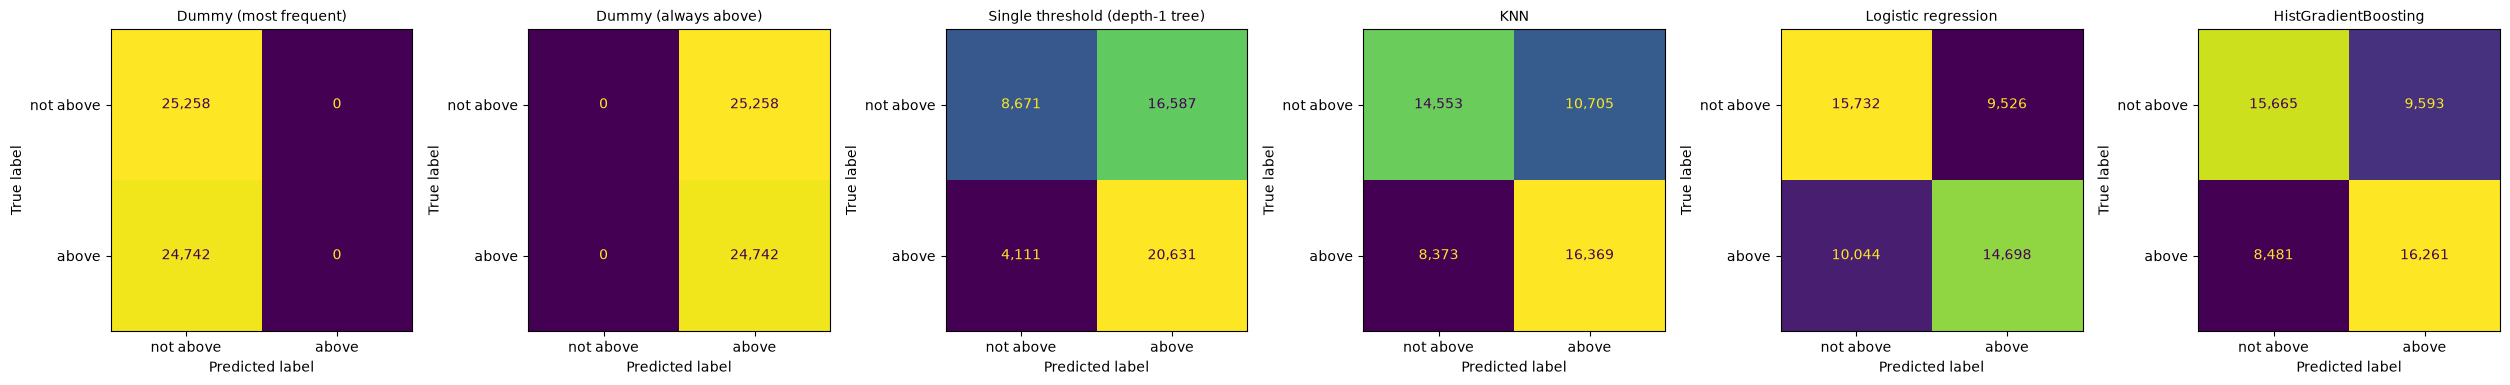

In [19]:
fig, axes = plt.subplots(1, len(final_models), figsize=(4.2 * len(final_models), 4))
for ax, (name, (pred, _)) in zip(axes, preds.items()):
    ConfusionMatrixDisplay(confusion_matrix(y_test, pred), display_labels=["not above", "above"]).plot(
        ax=ax, colorbar=False, values_format=",")
    ax.set_title(name, fontsize=10)
plt.tight_layout(); plt.show()

**Train vs CV vs test.**
* **CV and test agree for every model** (within 0.006 ROC-AUC). The CV estimate was honest, and the test set (other households, never used for any choice) confirms it.
* **HistGradientBoosting** scores clearly higher on its own training data (0.76) than on CV/test (0.69): it overfits a bit, but the test score is still the best of all models.
* **KNN** has a smaller gap (0.69 vs 0.66). Part of its training score is optimistic because each training point counts as its own neighbour.
* **Logistic regression** has almost no gap (0.66 vs 0.65), but it is low everywhere: it **underfits**, because one straight-line boundary cannot learn interactions such as
  "age pays off more in some occupations".
* **The F1 column shows why F1 was dropped:** "always above" (0.662) and the single threshold (0.666) have a *higher* F1 than every real model, yet they cannot rank anyone (ROC-AUC 0.50 and 0.59).
* **In absolute terms all models are modest.** A ROC-AUC of 0.69 means: for a random above-median and below-median worker, HGB ranks them correctly about 7 times in 10.
  The job profile explains part, but not most, of who earns above their median. The rest is employer, tenure, performance, negotiation and also discrimination, none of which the data contain.

## 8. Look at the errors

We look more closely at the model with the **best cross-validation ROC-AUC**. It is chosen on CV, not on the test set.

In [20]:
best_name = max(searches, key=lambda n: cv_rows[n]["cv_mean"])
best_model = final_models[best_name]
pred, prob = preds[best_name]
err = test_s.assign(pred=pred, prob=prob)
err["outcome"] = np.select([(err.y == 1) & (err.pred == 1), (err.y == 0) & (err.pred == 1), (err.y == 1) & (err.pred == 0)],
                           ["TP", "FP", "FN"], "TN")
print("best model by CV ROC-AUC:", best_name)

err["hours_band"] = pd.cut(err.WKHP, [0, 34, 44, 99], labels=["<35 h (part-time)", "35-44 h", "45+ h"])
err["age_band"] = pd.cut(err.AGEP, [17, 24, 34, 49, 64], labels=["18-24", "25-34", "35-49", "50-64"])
for col in ["hours_band", "age_band"]:
    print(pd.crosstab(err[col], err.outcome, normalize="index").round(3)[["TP", "FP", "FN", "TN"]], "\n")

best model by CV ROC-AUC: HistGradientBoosting
outcome               TP     FP     FN     TN
hours_band                                   
<35 h (part-time)  0.155  0.119  0.240  0.486
35-44 h            0.355  0.209  0.158  0.278
45+ h              0.372  0.199  0.148  0.281 

outcome      TP     FP     FN     TN
age_band                            
18-24     0.035  0.030  0.224  0.712
25-34     0.135  0.093  0.282  0.491
35-49     0.418  0.239  0.140  0.203
50-64     0.478  0.277  0.099  0.146 



In [21]:
# the most confident wrong 'above median' predictions = the people who would get the strongest wrong 'you may be underpaid' signal
show = ["OCCP", "STATE", "AGEP", "SCHL", "WKHP", "WKWN", "COW", "hourly", "cell_median", "prob"]
fp = err[err.outcome == "FP"].nlargest(8, "prob")[show].assign(occupation=lambda d: d.OCCP.map(OCC_LABEL),
                                                               state=lambda d: d.STATE.map(STATE_LABEL))
fp.round(2)

,OCCP,STATE,AGEP,SCHL,WKHP,WKWN,COW,hourly,cell_median,prob,occupation,state
76959,5860,17,63,21.0,40.0,52.0,5.0,16.99,19.54,0.92,"OFF-Office Clerks, General",Illinois/IL
177090,5240,47,55,21.0,40.0,9.0,1.0,17.20,17.57,0.90,OFF-Customer Service Representatives,Tennessee/TN
128594,5240,36,54,22.0,40.0,52.0,1.0,18.06,20.01,0.89,OFF-Customer Service Representatives,New York/NY
205695,1220,51,56,22.0,40.0,52.0,5.0,52.71,58.57,0.89,CMM-Operations Research Analysts,Virginia/VA
195788,3820,48,53,23.0,40.0,52.0,5.0,37.58,42.22,0.89,PRT-Detectives And Criminal Investigators,Texas/TX
213844,5240,55,39,21.0,40.0,52.0,1.0,13.18,20.74,0.89,OFF-Customer Service Representatives,Wisconsin/WI
55964,1050,12,56,21.0,40.0,52.0,5.0,26.85,30.26,0.88,CMM-Computer Support Specialists,Florida/FL
156085,5240,39,43,21.0,40.0,52.0,1.0,19.52,19.52,0.88,OFF-Customer Service Representatives,Ohio/OH


### Performance per group

The sensitive columns were **not** given to the model. Here we use them to check whether its mistakes are spread evenly.
*FPR* = share of below-median workers wrongly predicted "above" (would receive a wrong signal); *FNR* = share of above-median workers missed.

In [22]:
def group_report(d, col, p="pred"):
    out = {}
    for g, s in d.groupby(col, observed=True):
        tn, fp_, fn, tp = confusion_matrix(s.y, s[p], labels=[0, 1]).ravel()
        out[g] = {"n": len(s), "actual above": s.y.mean(), "predicted above": s[p].mean(),
                  "precision": tp / max(tp + fp_, 1), "recall": tp / max(tp + fn, 1),
                  "F1": f1_score(s.y, s[p], zero_division=0),
                  "FPR": fp_ / max(fp_ + tn, 1), "FNR": fn / max(fn + tp, 1)}
    return pd.DataFrame(out).T.round(3)

for col in AUDIT:
    display(group_report(err, col))
err["sector"] = err.occ_group + " – " + err.occ_group.map(OCC_GROUP_NAME)
group_report(err, "sector").sort_values("F1")

,n,actual above,predicted above,precision,recall,F1,FPR,FNR
female,24912.0,0.455,0.501,0.584,0.643,0.612,0.383,0.357
male,25088.0,0.535,0.533,0.671,0.669,0.670,0.376,0.331


,n,actual above,predicted above,precision,recall,F1,FPR,FNR
Asian,3871.0,0.536,0.608,0.637,0.723,0.677,0.476,0.277
Black,3785.0,0.469,0.523,0.593,0.661,0.625,0.402,0.339
Hispanic,8890.0,0.434,0.421,0.560,0.542,0.551,0.327,0.458
Other/multiple,2723.0,0.466,0.472,0.614,0.621,0.618,0.341,0.379
White,30731.0,0.513,0.537,0.649,0.679,0.664,0.387,0.321


,n,actual above,predicted above,precision,recall,F1,FPR,FNR
born US citizen,41802.0,0.492,0.501,0.636,0.648,0.642,0.359,0.352
naturalised citizen,4417.0,0.561,0.661,0.636,0.749,0.688,0.548,0.251
non-citizen,3781.0,0.448,0.527,0.540,0.635,0.584,0.439,0.365


,n,actual above,predicted above,precision,recall,F1,FPR,FNR
"FFF – Farming, fishing and forestry",257.0,0.486,0.300,0.545,0.336,0.416,0.265,0.664
"EXT – Extraction (mining, oil and gas)",16.0,0.500,0.250,0.750,0.375,0.500,0.125,0.625
CLN – Building and grounds cleaning and maintenance,1318.0,0.507,0.420,0.603,0.500,0.547,0.338,0.500
EAT – Food preparation and serving,2563.0,0.477,0.501,0.564,0.593,0.578,0.418,0.407
PRS – Personal care and service,706.0,0.508,0.411,0.655,0.529,0.586,0.288,0.471
HLS – Healthcare support,1651.0,0.499,0.532,0.576,0.614,0.595,0.450,0.386
TRN – Transportation and material moving,3634.0,0.506,0.511,0.612,0.618,0.615,0.401,0.382
PRD – Production,2250.0,0.498,0.563,0.585,0.661,0.620,0.465,0.339
CON – Construction,1879.0,0.489,0.521,0.602,0.641,0.621,0.406,0.359
MED – Healthcare practitioners and technical,3356.0,0.496,0.483,0.634,0.618,0.626,0.351,0.382


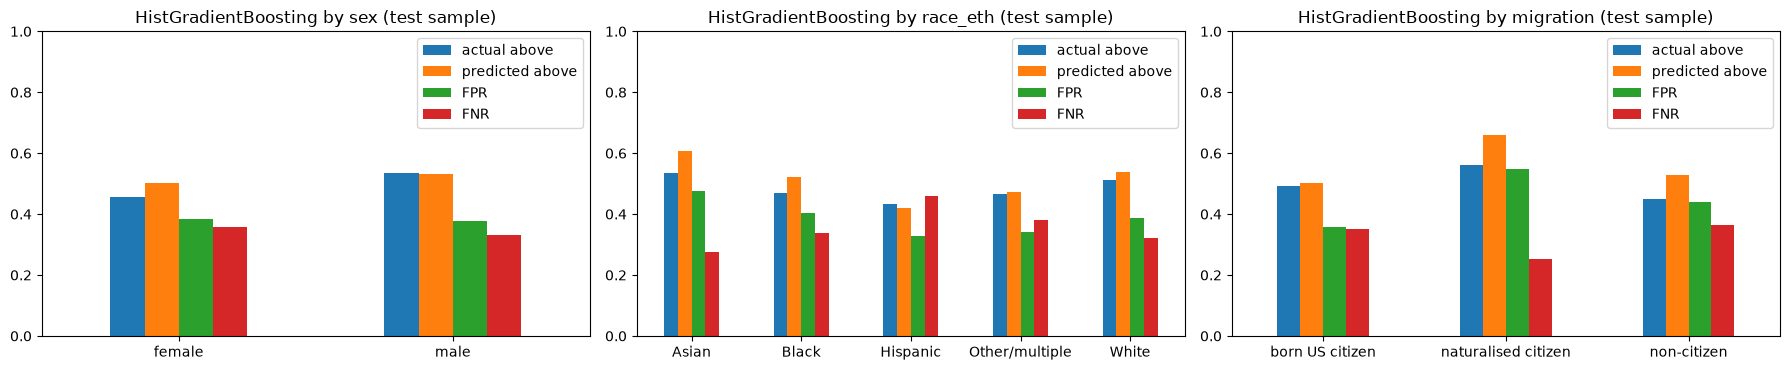

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 3.8))
for ax, col in zip(axes, AUDIT):
    group_report(err, col)[["actual above", "predicted above", "FPR", "FNR"]].plot.bar(ax=ax, rot=0)
    ax.set(title=f"{best_name} by {col} (test sample)", ylim=(0, 1))
plt.tight_layout(); plt.show()

### Rare occupations in the tuning sample

The 30-worker rule makes each *median* reliable, and it is checked on all ~870k training workers. The models, however, learn from the 20k tuning sample,
where many occupations appear only a few times or not at all. An occupation the model never saw becomes all zeros in the one-hot encoding,
so the model falls back on the occupation group, age, education and hours. Does that make predictions worse? We group the test workers by how often their occupation appears in the tuning sample.

In [24]:
occ_n = tune.OCCP.value_counts()
covered_occ = covered_cells.OCCP.drop_duplicates()
print(f"{len(covered_occ)} occupations are covered in at least one state; {len(occ_n)} appear in the tuning sample; "
      f"{(~covered_occ.isin(occ_n.index)).sum()} covered occupations never appear in it")

err["occ_in_tune"] = pd.cut(err.OCCP.map(occ_n).fillna(0), [-1, 0, 9, 49, np.inf],
                            labels=["0 (unseen)", "1-9", "10-49", "50+"])
rows = {}
for band in err.occ_in_tune.cat.categories:
    mask = (err.occ_in_tune == band).to_numpy()
    if mask.sum() == 0:  # no test worker in this band
        continue
    rows[band] ={"test workers": mask.sum(), "share of test": mask.mean(),
                  **{f"ROC-AUC {name}": roc_auc_score(y_test[mask], preds[name][1][mask]) for name in searches}}
pd.DataFrame(rows).T.rename_axis("workers with this occupation in the tuning sample").round(3)

409 occupations are covered in at least one state; 387 appear in the tuning sample; 22 covered occupations never appear in it


,test workers,share of test,ROC-AUC KNN,ROC-AUC Logistic regression,ROC-AUC HistGradientBoosting
workers with this occupation in the tuning sample,,,,,
0 (unseen),64.0,0.001,0.719,0.667,0.739
1-9,1453.0,0.029,0.673,0.660,0.678
10-49,6592.0,0.132,0.660,0.638,0.688
50+,41891.0,0.838,0.665,0.648,0.695


**Result: the small sample costs little.**
* 22 of the 409 covered occupations never appear in the tuning sample, but they account for only 64 test workers (0.1%). That is too few to judge their score.
* Workers whose occupation appears only 1–9 times (3% of the test set) get a slightly lower ROC-AUC from HistGradientBoosting (0.68 vs 0.69–0.70 for common occupations).
  With about 1,500 workers, this difference is within normal variation.
* **84% of test workers** have an occupation that appears 50+ times in the sample.
* This fits the design: the target is already defined *per occupation*, so the occupation on its own predicts almost nothing. The models mainly use age, education, hours and weeks, which every sampled worker contributes to.

**Proxy check.** Removing sex, race and citizenship from the features does not mean the model cannot "see" them. Occupation, industry and hours differ strongly between groups.
We test how well the model's own features predict each sensitive attribute (logistic regression, same folds). A ROC-AUC of 0.5 means "no information" and 1.0 means "perfectly hidden in the features".

In [25]:
proxy = {}
for target_name, target in [("female", tune.sex == "female"), ("non-citizen", tune.migration == "non-citizen"),
                            ("Black", tune.race_eth == "Black"), ("Hispanic", tune.race_eth == "Hispanic")]:
    pipe = Pipeline([("prep", make_preprocessor()), ("model", LogisticRegression(max_iter=2000))])
    proxy[target_name] = cross_validate(pipe, X_tune, target, cv=folds, scoring="roc_auc")["test_score"].mean()
pd.Series(proxy, name="ROC-AUC of predicting it from the model's features").round(3).to_frame()

,ROC-AUC of predicting it from the model's features
female,0.810
non-citizen,0.715
Black,0.627
Hispanic,0.676


### Mitigation: a stricter threshold for the "underpaid" signal

A wrong signal is the most visible harm. So the advice centre should not raise it at the default threshold of 0.5. We choose a threshold on the **training sample**
(out-of-fold probabilities, same folds, the test set is not used) so that at least **80% of "above median" predictions are correct**. We then report what that threshold does on the test set and per group.

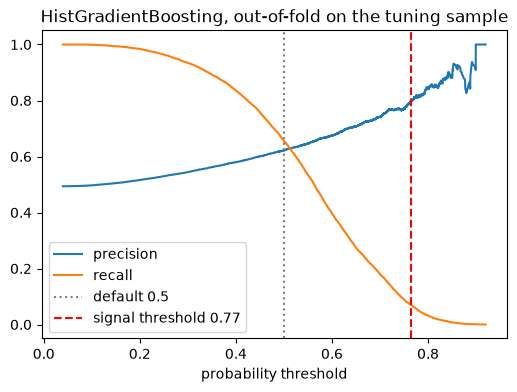

threshold 0.765 on the test sample: precision 0.794, recall 0.068 (at 0.5: precision 0.629, recall 0.657)


,n,precision,recall,FPR,FNR
female,24912.0,0.748,0.062,0.018,0.938
male,25088.0,0.831,0.072,0.017,0.928


,n,precision,recall,FPR,FNR
Asian,3871.0,0.803,0.104,0.029,0.896
Black,3785.0,0.748,0.065,0.019,0.935
Hispanic,8890.0,0.726,0.039,0.011,0.961
Other/multiple,2723.0,0.701,0.054,0.020,0.946
White,30731.0,0.814,0.072,0.017,0.928


,n,precision,recall,FPR,FNR
born US citizen,41802.0,0.799,0.064,0.015,0.936
naturalised citizen,4417.0,0.797,0.114,0.037,0.886
non-citizen,3781.0,0.718,0.053,0.017,0.947


In [26]:
TARGET_PRECISION = 0.80
oof_prob = cross_val_predict(clone(best_model), X_tune, y_tune, cv=folds, method="predict_proba")[:, 1]
prec, rec, thr = precision_recall_curve(y_tune, oof_prob)
FLAG_THRESHOLD = float(thr[np.argmax(prec[:-1] >= TARGET_PRECISION)])  # lowest threshold that reaches the target precision

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(thr, prec[:-1], label="precision"); ax.plot(thr, rec[:-1], label="recall")
ax.axvline(0.5, color="grey", ls=":", label="default 0.5")
ax.axvline(FLAG_THRESHOLD, color="red", ls="--", label=f"signal threshold {FLAG_THRESHOLD:.2f}")
ax.set(xlabel="probability threshold", title=f"{best_name}, out-of-fold on the tuning sample"); ax.legend()
plt.show()

err["flag_pred"] = (err.prob >= FLAG_THRESHOLD).astype(int)
print(f"threshold {FLAG_THRESHOLD:.3f} on the test sample: precision {precision_score(err.y, err.flag_pred):.3f}, "
      f"recall {recall_score(err.y, err.flag_pred):.3f} (at 0.5: precision {precision_score(err.y, err.pred):.3f}, "
      f"recall {recall_score(err.y, err.pred):.3f})")
for col in AUDIT:
    display(group_report(err, col, p="flag_pred")[["n", "precision", "recall", "FPR", "FNR"]])

**What the errors tell us.**
* **Age dominates.** Workers under 25 are almost always predicted "below" (few false positives, many misses). Workers over 50 are mostly predicted "above",
  so most wrong "above" predictions are among workers aged 35+. Part-time workers are mostly predicted "below".
* **The most confident false positives** are older, highly educated people in lower-paid jobs (e.g. customer service representatives with a master's degree).
  The model learned "education and experience pay". For these people a signal *may* reflect underpayment, but it may just as well mean the degree is not used in this job (over-qualification).
  An adviser has to tell the difference; the model cannot.
* **Groups (default threshold):** for **women**, precision is 0.58 against 0.67 for men. The model, which never sees sex, predicts women "above" about as often as their profile suggests (50%),
  but only 46% of them actually are. This is the double-edged core of this tool. Statistically these are "false positives", but they are partly the within-occupation pay gap the tool is meant to make visible.
  The same holds, more weakly, for **non-citizens** (precision 0.54) and **Black** workers (0.59). **Hispanic** workers are the opposite: the model rarely predicts them "above" (FNR 0.46), so they would get *fewer* signals,
  probably because education and part-time work act as proxies.
* **Proxies are strong:** from occupation, industry, hours and education alone, a simple model recognises women with ROC-AUC 0.81 and non-citizens with 0.72. Leaving the sensitive columns out does not make the model blind to them.
* **Sectors:** performance is worst for farming/fishing/forestry (FFF), cleaning (CLN) and food service (EAT) jobs, which are low-paid jobs with little spread in pay, and best for science (SCI) and engineering (ENG) jobs.
  Extraction (EXT) has only 16 test workers, too few to judge.
* **Mitigation, strict threshold:** raising the signal only at probability ≥ 0.77 brings test precision to 0.79 (4 in 5 signals right), at the cost of recall 0.07: the signal is rare.
  The gap between groups stays (precision 0.75 for women vs 0.83 for men, 0.72 for non-citizens), so signals for these groups must be read with extra care. We report this gap instead of hiding it.

## 9. Recommendation

**Use HistGradientBoosting, only as a triage aid for advisers, with the strict signal threshold of 0.77.**
* It has the best ROC-AUC in cross-validation (0.688 ± 0.012) and on the test set (0.694). The gap to KNN (0.026) and logistic regression (0.043) is larger than the spread over the folds,
  and CV matched test, so the advantage is real. It also predicts quickly; KNN has to search 20,000 neighbours for every member.
* It is less explainable than logistic regression. We accept that because the output is not a decision about the member: it is a reason for a human adviser to look closer.
  An adviser can always explain the signal with the two numbers the tool shows: the cell median and the member's own wage.
* **Do not use it** to tell a member they *are* underpaid, in pay negotiations as evidence, for workers outside the covered population (self-employed, under 18 or over 64,
  occupations "not covered" in their state, non-US workers), or by employers to judge their staff.
* Why ML and not a simple rule: the best single-feature rule ranks workers barely better than a coin (ROC-AUC 0.59), and comparing the wage with the median alone cannot tell a young worker
  who is *expected* to earn less from an experienced one who is not.

## 10. Use it: check a new (made-up) worker

`check_pay` refuses to answer for a state × occupation cell with fewer than 30 training workers. Otherwise it compares the worker's wage with the training median,
gives the model's probability that people with this profile earn above it, and raises the signal only above the stricter threshold from step 8.
Codes: see the [PUMS data dictionary](https://www2.census.gov/programs-surveys/acs/tech_docs/pums/data_dict/PUMS_Data_Dictionary_2024.csv)
(e.g. education 16 = high-school diploma, 21 = bachelor's, 22 = master's; class of worker 1 = private for-profit, 3 = local government).

In [27]:
RECOMMENDED = best_name  # see step 9
model = final_models[RECOMMENDED]
cell_median = covered_cells.set_index(["STATE", "OCCP"]).cell_median

def check_pay(occupation, industry, state, age, education, hours_per_week, weeks_worked, class_of_worker, hourly_wage):
    if (state, occupation) not in cell_median.index:
        return f"Occupation {occupation} is not covered in state {state} (fewer than {MIN_CELL} comparable workers): no prediction."
    row = pd.DataFrame([{"AGEP": age, "SCHL": education, "WKHP": hours_per_week, "WKWN": weeks_worked,
                         "OCCP": occupation, "occ_group": OCC_LABEL[occupation].split("-", 1)[0],
                         "ind_group": IND_LABEL[industry].split("-", 1)[0], "COW": class_of_worker}])
    p = model.predict_proba(row[FEATURES])[0, 1]
    median = cell_median[(state, occupation)]
    lines = [f"{OCC_LABEL[occupation]} in {STATE_LABEL[state]}: median ${median:.2f}/h, this worker earns ${hourly_wage:.2f}/h.",
             f"Probability that people with this profile earn above the median: {p:.2f} (signal threshold {FLAG_THRESHOLD:.2f})."]
    if hourly_wage <= median and p >= FLAG_THRESHOLD:
        lines.append("SIGNAL: paid below the median although similar workers usually earn above it -> worth a closer look.")
    else:
        lines.append("No signal.")
    return "\n".join(lines)

# made-up case 1: customer service representative (OCCP 5240) at an insurance company (INDP 6991) in Ohio (39),
# 45 years old, master's degree, 40 h/week, 52 weeks, private for-profit employer, earning $17.50/hour
print(check_pay(occupation=5240, industry=6991, state=39, age=45, education=22,
                hours_per_week=40, weeks_worked=52, class_of_worker=1, hourly_wage=17.50), "\n")

# made-up case 2: registered nurse (OCCP 3255) in a hospital (INDP 8191) in Ohio, 41, bachelor's degree, earning $33/hour
print(check_pay(occupation=3255, industry=8191, state=39, age=41, education=21,
                hours_per_week=40, weeks_worked=52, class_of_worker=1, hourly_wage=33.0), "\n")

# made-up case 3: software developer (OCCP 1021) in Wyoming (56): too few comparable workers in the survey
print(check_pay(occupation=1021, industry=7380, state=56, age=30, education=21,
                hours_per_week=40, weeks_worked=52, class_of_worker=1, hourly_wage=45.0))

OFF-Customer Service Representatives in Ohio/OH: median $19.52/h, this worker earns $17.50/h.
Probability that people with this profile earn above the median: 0.81 (signal threshold 0.77).
SIGNAL: paid below the median although similar workers usually earn above it -> worth a closer look. 

MED-Registered Nurses in Ohio/OH: median $38.07/h, this worker earns $33.00/h.
Probability that people with this profile earn above the median: 0.49 (signal threshold 0.77).
No signal. 

Occupation 1021 is not covered in state 56 (fewer than 30 comparable workers): no prediction.


**This is a signal, not proof.** The model compares a worker with similar workers in the survey. It cannot see performance, the employer, tenure,
collective agreements or negotiation, and it inherits existing pay patterns, including whole occupations that are underpaid. See the README for the ethical reflection.